In [5]:
#imports
import os
import random
#picks random image from the dataset and displays it
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
#open image files and reads their properties
import warnings
#suppresses unnecessarywarnings message in output
warnings.filterwarnings("ignore")


In [2]:
#paths

TRAIN_DIR = "../dataset/train"
VAL_DIR = "../dataset/val"

classes=sorted(os.listdir(TRAIN_DIR))

print(f"Total classes: {len(classes)}")
print(f"\nALl classes")

for i,cls in enumerate(classes):
    print(f" {i+1}. {cls}")

#classes names are arranged alphabetically

Total classes: 38

ALl classes
 1. Apple___Apple_scab
 2. Apple___Black_rot
 3. Apple___Cedar_apple_rust
 4. Apple___healthy
 5. Blueberry___healthy
 6. Cherry_(including_sour)___Powdery_mildew
 7. Cherry_(including_sour)___healthy
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 9. Corn_(maize)___Common_rust_
 10. Corn_(maize)___Northern_Leaf_Blight
 11. Corn_(maize)___healthy
 12. Grape___Black_rot
 13. Grape___Esca_(Black_Measles)
 14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 15. Grape___healthy
 16. Orange___Haunglongbing_(Citrus_greening)
 17. Peach___Bacterial_spot
 18. Peach___healthy
 19. Pepper,_bell___Bacterial_spot
 20. Pepper,_bell___healthy
 21. Potato___Early_blight
 22. Potato___Late_blight
 23. Potato___healthy
 24. Raspberry___healthy
 25. Soybean___healthy
 26. Squash___Powdery_mildew
 27. Strawberry___Leaf_scorch
 28. Strawberry___healthy
 29. Tomato___Bacterial_spot
 30. Tomato___Early_blight
 31. Tomato___Late_blight
 32. Tomato___Leaf_Mold
 33. Tomato___

In [3]:
#Count images in each class

print(f"{'Class Name':<45} {'Train':>7} {'Val':>7} {'Total':>7}")
print("-" * 70)

train_counts = {}
val_counts = {}

for cls in classes:
    train_folder=os.path.join(TRAIN_DIR,cls)
    val_folder=os.path.join(VAL_DIR,cls)

    train_imgs= [
        f for f in os.listdir(train_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    
    val_imgs= [
        f for f in os.listdir(val_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    train_counts[cls] = len(train_imgs)
    val_counts[cls] = len(val_imgs)

    print(f"{cls:<45} {train_counts[cls]:>7} {val_counts[cls]:>7} {train_counts[cls] + val_counts[cls]:>7}")

total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
print("-" * 70)
print(f"{'Total':<45} {total_train:>7} {total_val:>7} {total_train + total_val:>7}")

Class Name                                      Train     Val   Total
----------------------------------------------------------------------
Apple___Apple_scab                                504     126     630
Apple___Black_rot                                 496     125     621
Apple___Cedar_apple_rust                          220      55     275
Apple___healthy                                  1316     329    1645
Blueberry___healthy                              1201     301    1502
Cherry_(including_sour)___Powdery_mildew          841     211    1052
Cherry_(including_sour)___healthy                 683     171     854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     410     103     513
Corn_(maize)___Common_rust_                       953     239    1192
Corn_(maize)___Northern_Leaf_Blight               788     197     985
Corn_(maize)___healthy                            929     233    1162
Grape___Black_rot                                 944     236    1180
Grape___Esca_(

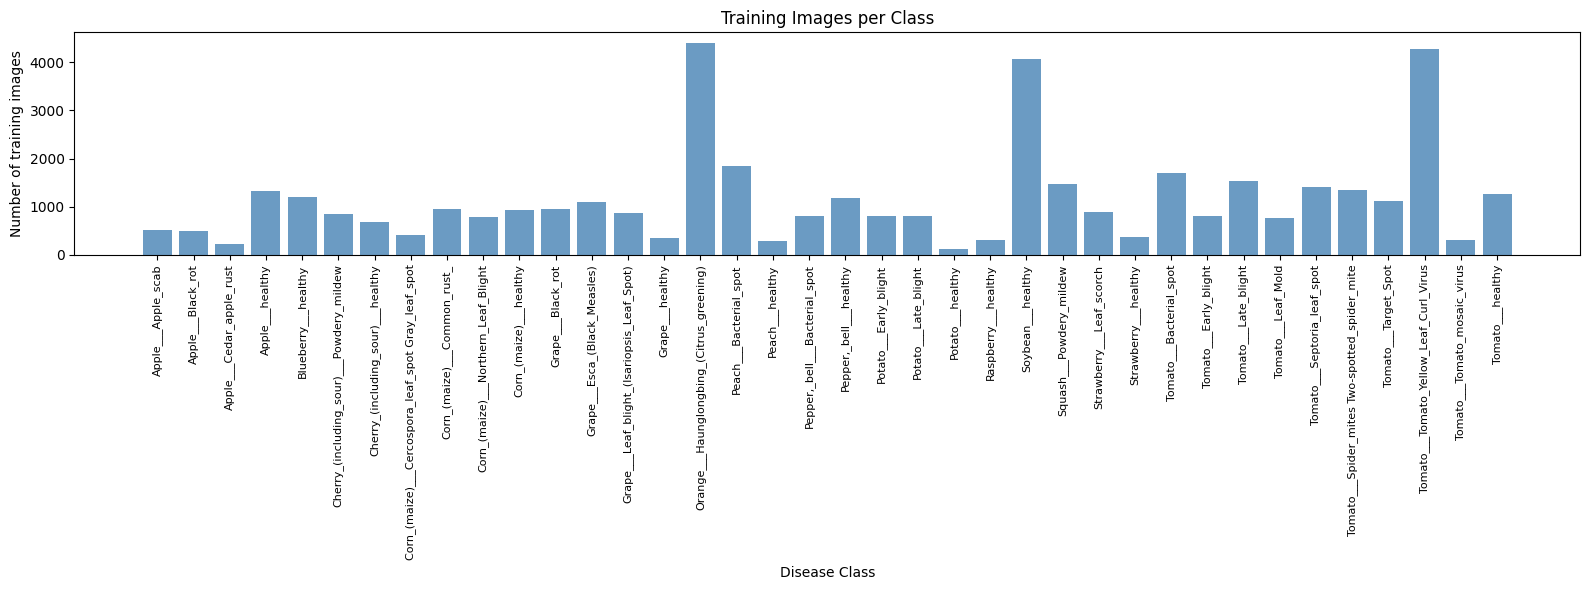

In [6]:
#Bar chart of imagr count

plt.figure(figsize=(16, 6))
#creates a blank canvas to draw on, 16 inches wide and 6 inches tall

#creating bars
bars=plt.bar(
    range(len(classes)),   #produces [0,1,2,.....,37] where one bar sits horizontally
    list(train_counts.values()), 
    color='steelblue',
    alpha=0.8  #transparency level
)    

#adding labels
plt.xticks(
    range(len(classes)), #tells where to place the labels on x-axis
    classes, #labels for each bar, class names
    rotation=90, #rotates the labels by 90 degrees
    fontsize=8   
)

plt.xlabel("Disease Class")
plt.ylabel("Number of training images")
plt.title("Training Images per Class")

plt.tight_layout()   #auto-adjusts all spacing inside the graph

plt.savefig("class_distribution.png", dpi=300)  
#saves the graph as a png file in your project folder

plt.show()
#displays the graph